## 1. Das Drive mit den Dateien Mounten

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive eingebunden unter /content/drive/MyDrive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive eingebunden unter /content/drive/MyDrive


In [4]:
# ── Installs ────────────────────────────────────────────────────────────────
!pip install pygltflib pyproj matplotlib geopandas contextily numpy trimesh tqdm scipy

## 2. Einlesen der GLB-Datei

In [5]:
import os

# ── HIER ANPASSEN ──────────────────────────────────────────────
DRIVE_FOLDER  = '/content/drive/MyDrive/Transformation'
GLB_FILENAME  = 'gebaeude_georef.glb'   # <-- deinen GLB-Dateinamen eintragen
# ───────────────────────────────────────────────────────────────

glb_path = os.path.join(DRIVE_FOLDER, GLB_FILENAME)
out_name  = GLB_FILENAME.replace('.glb', '_local.glb')
out_path  = os.path.join(DRIVE_FOLDER, out_name)

assert os.path.exists(glb_path), f'Datei nicht gefunden: {glb_path}'
print(f'Eingabe:  {glb_path}')
print(f'Ausgabe:  {out_path}')

# Alle Dateien im Ordner anzeigen
print(f'\nDateien in {DRIVE_FOLDER}:')
for f in sorted(os.listdir(DRIVE_FOLDER)):
    size_mb = os.path.getsize(os.path.join(DRIVE_FOLDER, f)) / 1e6
    print(f'  {f}  ({size_mb:.1f} MB)')

Eingabe:  /content/drive/MyDrive/Transformation/gebaeude_georef.glb
Ausgabe:  /content/drive/MyDrive/Transformation/gebaeude_georef_local.glb

Dateien in /content/drive/MyDrive/Transformation:
  3mio.ply  (466.0 MB)
  Karte.png  (1.8 MB)
  Transformationmatrix.txt  (0.0 MB)
  Transformationsmatrix_ResiduenAusgleich.png  (0.1 MB)
  gebaeude_georef.glb  (0.2 MB)
  gebaeude_splat.ply  (173.9 MB)
  images_georef.txt  (284.0 MB)
  images_nongeoref.txt  (284.0 MB)
  plaetze.glb  (0.0 MB)
  plaetze_splat.ply  (10.3 MB)
  strassen.glb  (0.0 MB)
  strassen_splat.ply  (3.6 MB)


## 3. Check ob die Grunddaten richtig Georeferenziert sind

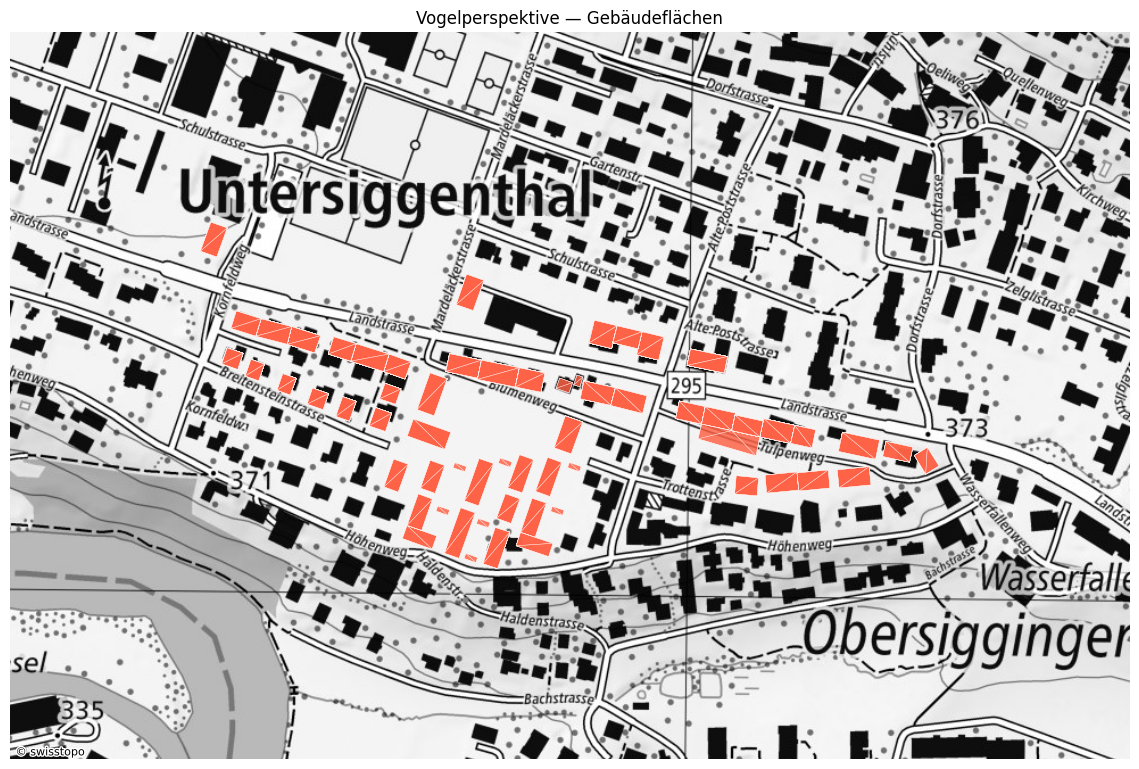

In [6]:
# ── Variabeln ────────────────────────────────────────────────────────────────
path_glb = glb_path

# ── Import ────────────────────────────────────────────────────────────────
import os, pyproj
os.environ["PROJ_DATA"] = pyproj.datadir.get_data_dir()
os.environ["PROJ_LIB"]  = pyproj.datadir.get_data_dir()

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
import geopandas as gpd
import contextily as ctx
from pygltflib import GLTF2
from pyproj import Transformer

# ── GLB laden ────────────────────────────────────────────────────────────────
gltf = GLTF2().load(path_glb)
binary = gltf.binary_blob()

transformer = Transformer.from_crs("EPSG:2056", "EPSG:3857", always_xy=True)

all_polys = []

for mesh in gltf.meshes:
    for prim in mesh.primitives:
        if prim.indices is None:
            continue
        acc   = gltf.accessors[prim.attributes.POSITION]
        bv    = gltf.bufferViews[acc.bufferView]
        start = (bv.byteOffset or 0) + (acc.byteOffset or 0)
        v = np.frombuffer(binary[start : start + acc.count * 12],
                          dtype=np.float32).reshape(-1, 3)

        easting  =  v[:, 0].astype(np.float64)
        northing = -v[:, 2].astype(np.float64)
        xwm, ywm = transformer.transform(easting, northing)

        iacc   = gltf.accessors[prim.indices]
        ibv    = gltf.bufferViews[iacc.bufferView]
        istart = (ibv.byteOffset or 0) + (iacc.byteOffset or 0)
        dtype  = {5121: np.uint8, 5123: np.uint16, 5125: np.uint32}[iacc.componentType]
        idx    = np.frombuffer(binary[istart : istart + iacc.count * np.dtype(dtype).itemsize],
                               dtype=dtype).reshape(-1, 3)

        for tri in idx:
            all_polys.append(np.column_stack([xwm[tri], ywm[tri]]))

# ── Extent ───────────────────────────────────────────────────────────────────
all_pts = np.vstack(all_polys)
pad = 200
xmin, ymin = all_pts[:, 0].min() - pad, all_pts[:, 1].min() - pad
xmax, ymax = all_pts[:, 0].max() + pad, all_pts[:, 1].max() + pad

# ── Figurgrösse nach Seitenverhältnis der BBOX ───────────────────────────────
dx, dy = xmax - xmin, ymax - ymin
fig, ax = plt.subplots(figsize=(12, 12 * dy / dx))

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')   # ← Verzerrung verhindern

ctx.add_basemap(ax, crs=None,
                source=ctx.providers.SwissFederalGeoportal.NationalMapGrey,
                zorder=1)

col = PolyCollection(all_polys, facecolor="tomato", edgecolor="white",
                     linewidth=0.3, alpha=0.6, zorder=2)
ax.add_collection(col)

ax.set_axis_off()
ax.set_title("Vogelperspektive — Gebäudeflächen")
plt.tight_layout()
out_str = DRIVE_FOLDER + "/Karte.png"
plt.savefig(out_str, dpi=150, bbox_inches="tight")
plt.show()

##4. GLB im LichtFeld-Studio mit dem Tool "Meshtosplat" in ein 3DGS umwandeln (.ply-file)

##5. Berechnung der Transformationsmatrix aus dem COLMAP Export LV95 und Lokal (Ausgleichung MdkQ)

Gemeinsame Kameras: 2762

Transformationsmatrix alt → neu:
[[       0.999968        0.010447        0.000011 -2674795.953962]
 [       0.000011        0.000018       -1.000023      -51.427823]
 [      -0.010447        0.999968        0.000018 -1233273.345313]
 [       0.              0.              0.              1.      ]]

Residuen — Mean: 0.0067 m, Max: 0.0289 m


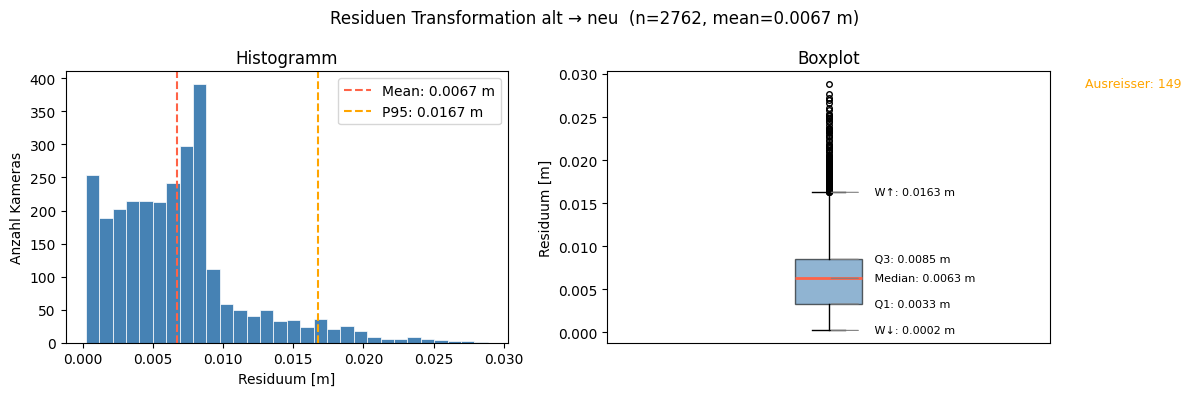

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

def parse_images_txt(path):
    """Gibt dict {name: position_xyz} zurück."""
    cameras = {}
    with open(path) as f:
        lines = [l.strip() for l in f if not l.startswith("#") and l.strip()]
    i = 0
    while i < len(lines):
        parts = lines[i].split()
        qw, qx, qy, qz = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        tx, ty, tz     = float(parts[5]), float(parts[6]), float(parts[7])
        name = parts[9]

        # Kameraposition im Weltkoordinatensystem: C = -R^T @ t
        R = Rotation.from_quat([qx, qy, qz, qw]).as_matrix()
        t = np.array([tx, ty, tz])
        C = -R.T @ t

        cameras[name] = C
        i += 2  # jede Kamera belegt 2 Zeilen
    return cameras

# ── Einlesen ──────────────────────────────────────────────────────────────────
cams_alt = parse_images_txt("/content/drive/MyDrive/Transformation/images_georef.txt")
cams_neu = parse_images_txt("/content/drive/MyDrive/Transformation/images_nongeoref.txt")

# Nur gemeinsame Kameras verwenden
common = sorted(set(cams_alt.keys()) & set(cams_neu.keys()))
print(f"Gemeinsame Kameras: {len(common)}")

# pts_alt = np.array([cams_alt[n] for n in common])  # (N, 3)
# pts_neu = np.array([cams_neu[n] for n in common])  # (N, 3)

pts_alt = np.array([cams_alt[n] for n in common])
pts_neu = np.array([cams_neu[n] for n in common])

# NEU ↓
pts_neu = np.stack([pts_neu[:,0], -pts_neu[:,2], pts_neu[:,1]], axis=1)


# ── Umbalas-Horn: optimale Rigid-Body-Transformation (R, t, s) ───────────────
def estimate_transform(src, dst):
    """Schätzt T (4×4) mit Skalierung: dst ≈ s * R @ src + t"""
    mu_src = src.mean(axis=0)
    mu_dst = dst.mean(axis=0)
    src_c = src - mu_src
    dst_c = dst - mu_dst

    # Skalierung
    s = np.sqrt((dst_c ** 2).sum() / (src_c ** 2).sum())

    # Rotation via SVD
    H = src_c.T @ dst_c
    U, _, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:  # Reflection fix
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    # Translation
    t = mu_dst - s * R @ mu_src

    # 4×4 Matrix
    T = np.eye(4)
    T[:3, :3] = s * R
    T[:3,  3] = t
    return T

T = estimate_transform(pts_alt, pts_neu)

print("\nTransformationsmatrix alt → neu:")
print(np.array2string(T, precision=6, suppress_small=True))

# Residuen prüfen
pts_alt_h = np.hstack([pts_alt, np.ones((len(pts_alt), 1))])
pts_transformed = (T @ pts_alt_h.T).T[:, :3]
residuals = np.linalg.norm(pts_transformed - pts_neu, axis=1)
print(f"\nResiduen — Mean: {residuals.mean():.4f} m, Max: {residuals.max():.4f} m")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histogramm
ax1.hist(residuals, bins=30, color="steelblue", edgecolor="white", linewidth=0.5)
ax1.axvline(residuals.mean(), color="tomato", linestyle="--", label=f"Mean: {residuals.mean():.4f} m")
ax1.axvline(np.percentile(residuals, 95), color="orange", linestyle="--", label=f"P95: {np.percentile(residuals, 95):.4f} m")
ax1.set_xlabel("Residuum [m]")
ax1.set_ylabel("Anzahl Kameras")
ax1.set_title("Histogramm")
ax1.legend()

# Boxplot
bp = ax2.boxplot(residuals, vert=True, patch_artist=True,
                 boxprops=dict(facecolor="steelblue", alpha=0.6),
                 medianprops=dict(color="tomato", linewidth=2),
                 flierprops=dict(marker="o", color="orange", markersize=4))
ax2.set_ylabel("Residuum [m]")
ax2.set_title("Boxplot")
ax2.set_xticks([])

# Quantile als Zahlen annotieren
q1, med, q3 = np.percentile(residuals, [25, 50, 75])
iqr = q3 - q1
whisker_low  = max(residuals.min(), q1 - 1.5 * iqr)
whisker_high = min(residuals.max(), q3 + 1.5 * iqr)
outliers = residuals[(residuals < whisker_low) | (residuals > whisker_high)]

for val, label in [(q1, f"   Q1: {q1:.4f} m"), (med, f"   Median: {med:.4f} m"), (q3, f"   Q3: {q3:.4f} m"),
                   (whisker_low, f"   W↓: {whisker_low:.4f} m"), (whisker_high, f"   W↑: {whisker_high:.4f} m")]:
    ax2.annotate(label, xy=(1, val), xytext=(1.08, val),
                 fontsize=8, va="center",
                 arrowprops=dict(arrowstyle="-", color="gray", lw=0.8))

ax2.text(1.08, ax2.get_ylim()[1] * 0.98,
         f"Ausreisser: {len(outliers)}",
         fontsize=9, color="orange", va="top",
         transform=ax2.get_yaxis_transform())

fig.suptitle(f"Residuen Transformation alt → neu  (n={len(residuals)}, mean={residuals.mean():.4f} m)", fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Transformation/Transformationsmatrix_ResiduenAusgleich.png", dpi=150)
plt.show()

##6. Transformation Splats in Lokales System

In [12]:
import numpy as np
import struct
from scipy.spatial.transform import Rotation
from tqdm import tqdm

# ── Pfade ─────────────────────────────────────────────────────────
# INPUT_PLY  = '/content/drive/MyDrive/Transformation/gebaeude_splat.ply'
INPUT_PLY  = '/content/drive/MyDrive/Transformation/plaetze_splat.ply'
# INPUT_PLY  = '/content/drive/MyDrive/Transformation/strassen_splat.ply'
OUTPUT_PLY = INPUT_PLY.replace('.ply', '_local.ply')

# ── Matrizen ──────────────────────────────────────────────────────
T = T
R3 = T[:3, :3]
t3 = T[:3,  3]

# glTF → LV95 Achsendrehung
A = np.array([[1, 0, 0], [0, 0, -1], [0, 1, 0]], dtype=np.float64)
# Kombinierte Rotationsmatrix für Positionen: lokal = R3 @ A @ pos_gltf + t3
R_pos = R3 @ A          # (3x3)
# Zurück in glTF-Achsen: A.T @ local_pos
R_full = A.T @ R_pos    # (3x3) – direkt glTF→glTF (lokal)

# ── PLY Header lesen ──────────────────────────────────────────────
print("Lese PLY...")
with open(INPUT_PLY, 'rb') as f:
    raw = f.read()

header_end = raw.find(b'end_header\n') + len(b'end_header\n')
header     = raw[:header_end].decode('ascii')
body       = raw[header_end:]

n_verts = int([l for l in header.splitlines() if 'element vertex' in l][0].split()[-1])
props   = [l.split()[-1] for l in header.splitlines() if l.strip().startswith('property float')]
stride  = len(props) * 4
n_props = len(props)

print(f"  Vertices  : {n_verts:,}")
print(f"  Properties: {n_props}")
print(f"  Body      : {len(body):,} bytes")

# ── Alle Daten auf einmal als float32-Array laden ─────────────────
print("Parse Floats (vektorisiert)...")
data = np.frombuffer(body, dtype='<f4').reshape(n_verts, n_props).copy()

xi  = props.index('x')
yi  = props.index('y')
zi  = props.index('z')
r0i = props.index('rot_0')  # w
r1i = props.index('rot_1')  # x
r2i = props.index('rot_2')  # y
r3i = props.index('rot_3')  # z

has_normals = all(p in props for p in ['nx', 'ny', 'nz'])
if has_normals:
    nxi, nyi, nzi = props.index('nx'), props.index('ny'), props.index('nz')

# ── Positionen vektorisiert transformieren ────────────────────────
print("Transformiere Positionen...")
pos_gltf = data[:, [xi, yi, zi]].astype(np.float64)  # (N, 3)

# LV95-Positionen (für Plausibilitätsprüfung)
pos_lv95 = (A @ pos_gltf.T).T  # (N, 3)

# Lokal (E,N,H-System)
pos_local = (R_pos @ pos_gltf.T).T + t3  # (N, 3)

# Zurück in glTF-Achsen (A.T @ local)
pos_out = (A.T @ pos_local.T).T  # (N, 3)

data[:, xi] = pos_out[:, 0].astype(np.float32)
data[:, yi] = pos_out[:, 1].astype(np.float32)
data[:, zi] = pos_out[:, 2].astype(np.float32)

# ── Normalen vektorisiert ─────────────────────────────────────────
if has_normals:
    print("Transformiere Normalen...")
    nrm_gltf = data[:, [nxi, nyi, nzi]].astype(np.float64)
    nrm_local = (R_pos @ nrm_gltf.T).T
    norms = np.linalg.norm(nrm_local, axis=1, keepdims=True)
    norms[norms < 1e-8] = 1.0
    nrm_local /= norms
    nrm_out = (A.T @ nrm_local.T).T
    data[:, nxi] = nrm_out[:, 0].astype(np.float32)
    data[:, nyi] = nrm_out[:, 1].astype(np.float32)
    data[:, nzi] = nrm_out[:, 2].astype(np.float32)

# ── Quaternionen vektorisiert ─────────────────────────────────────
print("Transformiere Quaternionen...")
# rot: w=r0i, x=r1i, y=r2i, z=r3i → scipy erwartet [x,y,z,w]
quats_wxyz = data[:, [r0i, r1i, r2i, r3i]].astype(np.float64)
quats_xyzw = quats_wxyz[:, [1, 2, 3, 0]]  # → [x,y,z,w]

# Alle Rotationsmatrizen auf einmal
R_splats = Rotation.from_quat(quats_xyzw).as_matrix()  # (N, 3, 3)

# R_out = A.T @ R3 @ A @ R_splat @ A.T @ A  vereinfacht:
# = R_full @ R_splat  (im glTF-Raum direkt)
# Korrekte Formel: A.T @ (R3 @ (A @ R_splat @ A.T)) @ A
print("  Matrixmultiplikation (batch)...")
# (N,3,3): für jeden Splat: A.T @ R3 @ A @ R_splat
LHS = A.T @ R3 @ A  # (3,3) – konstant für alle Splats
R_out = LHS[np.newaxis] @ R_splats  # (N,3,3) broadcast

q_out = Rotation.from_matrix(R_out).as_quat()  # (N,4) → [x,y,z,w]
data[:, r0i] = q_out[:, 3].astype(np.float32)  # w
data[:, r1i] = q_out[:, 0].astype(np.float32)  # x
data[:, r2i] = q_out[:, 1].astype(np.float32)  # y
data[:, r3i] = q_out[:, 2].astype(np.float32)  # z

# ── Plausibilitätsprüfung ─────────────────────────────────────────
print(f"\n{'='*50}")
print("VORHER – LV95 (E, N, H):")
print(f"  E: [{pos_lv95[:,0].min():.1f},  {pos_lv95[:,0].max():.1f}]")
print(f"  N: [{pos_lv95[:,1].min():.1f},  {pos_lv95[:,1].max():.1f}]")
print(f"  H: [{pos_lv95[:,2].min():.1f},  {pos_lv95[:,2].max():.1f}]")
print("\nNACHHER – Lokal (E,N,H):")
print(f"  X: [{pos_local[:,0].min():.2f},  {pos_local[:,0].max():.2f}]")
print(f"  Y: [{pos_local[:,1].min():.2f},  {pos_local[:,1].max():.2f}]")
print(f"  Z: [{pos_local[:,2].min():.2f},  {pos_local[:,2].max():.2f}]")

center  = pos_local.mean(axis=0)
ply_ref = np.array([72.6, -337.3, -370.0])
dist    = np.linalg.norm(center - ply_ref)
print(f"\nGLB-Zentrum lokal : {np.round(center, 2)}")
print(f"PLY Header-Offset : {ply_ref}")
print(f"Abstand           : {dist:.1f} m")
print("✅ OK!" if dist < 2000 else "⚠️  Achsenzuordnung prüfen!")
print('='*50)

# ── Speichern ─────────────────────────────────────────────────────
print("\nSpeichere PLY...")
with open(OUTPUT_PLY, 'wb') as f:
    f.write(header.encode('ascii'))
    f.write(data.astype('<f4').tobytes())
print(f"✅ Gespeichert: {OUTPUT_PLY}")

Lese PLY...
  Vertices  : 151,972
  Properties: 17
  Body      : 10,334,096 bytes
Parse Floats (vektorisiert)...
Transformiere Positionen...
Transformiere Normalen...
Transformiere Quaternionen...
  Matrixmultiplikation (batch)...

VORHER – LV95 (E, N, H):
  E: [2661702.5,  2662109.5]
  N: [1261016.8,  1261242.4]
  H: [370.3,  373.2]

NACHHER – Lokal (E,N,H):
  X: [-1.37,  404.50]
  Y: [-373.17,  -370.28]
  Z: [-104.76,  122.55]

GLB-Zentrum lokal : [ 137.9  -371.43   54.91]
PLY Header-Offset : [  72.6 -337.3 -370. ]
Abstand           : 431.3 m
✅ OK!

Speichere PLY...
✅ Gespeichert: /content/drive/MyDrive/Transformation/plaetze_splat_local.ply


##7. Rotation eines beliebigen Splats.ply um die X-Achse um 90°
###Führt zur Kompabilität mit dem Supersplat Viewer

In [13]:
import numpy as np
import struct
import sys
from pathlib import Path


def rotate_3dgs_ply_x90(input_path: str) -> str:
    """
    Rotiert eine 3D Gaussian Splatting PLY-Datei um 90° um die X-Achse.
    Ausgabe: gleicher Ordner, Dateiname mit _rotated.ply
    """
    input_path = Path(input_path)
    output_path = input_path.parent / (input_path.stem + "_rotated.ply")

    # Rotationsmatrix: 90° um X-Achse
    # x' = x,  y' = -z,  z' = y
    R = np.array([
        [1,  0,  0],
        [0,  0, -1],
        [0,  1,  0],
    ], dtype=np.float32)

    with open(input_path, "rb") as f:
        # Header lesen
        header_lines = []
        while True:
            line = f.readline().decode("ascii", errors="replace").rstrip("\n").rstrip("\r")
            header_lines.append(line)
            if line == "end_header":
                break

        header_text = "\n".join(header_lines) + "\n"

        # Properties parsen
        num_vertices = 0
        properties = []
        format_type = "binary_little_endian"

        for line in header_lines:
            parts = line.split()
            if len(parts) < 2:
                continue
            if parts[0] == "element" and parts[1] == "vertex":
                num_vertices = int(parts[2])
            elif parts[0] == "format":
                format_type = parts[1]
            elif parts[0] == "property":
                dtype_str = parts[1]
                prop_name = parts[2]
                dtype_map = {
                    "float": ("f", 4), "float32": ("f", 4),
                    "double": ("d", 8),
                    "int": ("i", 4), "int32": ("i", 4),
                    "uint": ("I", 4), "uint32": ("I", 4),
                    "short": ("h", 2), "ushort": ("H", 2),
                    "uchar": ("B", 1), "char": ("b", 1),
                }
                fmt_char, byte_size = dtype_map.get(dtype_str, ("f", 4))
                properties.append((prop_name, fmt_char, byte_size))

        endian = "<" if "little" in format_type else ">"
        vertex_size = sum(b for _, _, b in properties)
        raw_data = f.read(num_vertices * vertex_size)

    prop_index = {name: i for i, (name, _, _) in enumerate(properties)}
    fmt = endian + "".join(c for _, c, _ in properties)

    vertices = [
        list(struct.unpack_from(fmt, raw_data, i * vertex_size))
        for i in range(num_vertices)
    ]

    ix = prop_index["x"]
    iy = prop_index["y"]
    iz = prop_index["z"]
    iq = [prop_index.get(f"rot_{j}") for j in range(4)]  # w, x, y, z

    # R_x(90°) als Quaternion: (w=cos45°, x=sin45°, y=0, z=0)
    import math
    half = math.pi / 4
    qr = [math.cos(half), math.sin(half), 0.0, 0.0]

    def quat_mul(q1, q2):
        w1, x1, y1, z1 = q1
        w2, x2, y2, z2 = q2
        return [
            w1*w2 - x1*x2 - y1*y2 - z1*z2,
            w1*x2 + x1*w2 + y1*z2 - z1*y2,
            w1*y2 - x1*z2 + y1*w2 + z1*x2,
            w1*z2 + x1*y2 - y1*x2 + z1*w2,
        ]

    for v in vertices:
        # Position rotieren
        x, y, z = v[ix], v[iy], v[iz]
        v[ix] = x
        v[iy] = -z
        v[iz] = y

        # Gaussian-Orientierung (Quaternion) rotieren
        if all(i is not None for i in iq):
            q_gs = [v[iq[0]], v[iq[1]], v[iq[2]], v[iq[3]]]
            norm = math.sqrt(sum(c**2 for c in q_gs))
            if norm > 1e-6:
                q_gs = [c / norm for c in q_gs]
            q_new = quat_mul(qr, q_gs)
            for j, val in enumerate(q_new):
                v[iq[j]] = float(val)

    # Datei schreiben
    out_data = bytearray()
    for v in vertices:
        out_data += struct.pack(fmt, *v)

    with open(output_path, "wb") as f:
        f.write(header_text.encode("ascii"))
        f.write(bytes(out_data))

    print(f"Gespeichert: {output_path}")
    return str(output_path)

In [14]:
path1 = "/content/drive/MyDrive/Transformation/gebaeude_splat_local.ply"
path2 = "/content/drive/MyDrive/Transformation/strassen_splat_local.ply"
path3 = "/content/drive/MyDrive/Transformation/plaetze_splat_local.ply"
path4 = "/content/drive/MyDrive/Transformation/3mio.ply"

rotate_3dgs_ply_x90(path1)
rotate_3dgs_ply_x90(path2)
rotate_3dgs_ply_x90(path3)
rotate_3dgs_ply_x90(path4)


Gespeichert: /content/drive/MyDrive/Transformation/gebaeude_splat_local_rotated.ply
Gespeichert: /content/drive/MyDrive/Transformation/strassen_splat_local_rotated.ply
Gespeichert: /content/drive/MyDrive/Transformation/plaetze_splat_local_rotated.ply
Gespeichert: /content/drive/MyDrive/Transformation/3mio_rotated.ply


'/content/drive/MyDrive/Transformation/3mio_rotated.ply'

##8. Alle PLY in der Liste werden zusammen gemergt und als alleinstehendes File exportiert

In [17]:
import numpy as np
from pathlib import Path
from typing import List, Tuple, Union


def merge_3dgs_ply(
    input_paths: List[str],
    colors: List[Union[Tuple[int, int, int], int]] = None
):
    """
    Merged mehrere 3DGS PLY-Dateien zu einer einzigen.
    Fehlende Properties werden automatisch mit Nullen aufgefüllt.
    Output: gleicher Ordner wie input_paths[0] → Final_Merged.ply

    Args:
        input_paths: Liste von Pfaden zu PLY-Dateien
        colors:      Liste von RGB-Tupeln (0–255) oder 9999 (= keine Änderung).
                     Muss gleiche Länge wie input_paths haben.
                     Beispiel: [(255, 0, 0), 9999, (0, 255, 0)]
    """
    # Validierung
    if colors is not None and len(colors) != len(input_paths):
        raise ValueError(
            f"colors ({len(colors)} Einträge) muss gleiche Länge wie "
            f"input_paths ({len(input_paths)}) haben."
        )

    SH_C0 = 0.28209479177387814  # SH DC Koeffizient

    input_path = Path(input_paths[0])
    output_path = input_path.parent / "Final_Merged.ply"
    all_verts = []
    all_properties = []

    for path in input_paths:
        path = Path(path)
        with open(path, "rb") as f:
            header_bytes = bytearray()
            while True:
                line = f.readline()
                header_bytes += line
                if line.strip() == b"end_header":
                    break
            hdr = header_bytes.decode("ascii", errors="replace")

            num_vertices = 0
            properties = []
            format_type = "binary_little_endian"

            for line in hdr.splitlines():
                parts = line.split()
                if len(parts) < 2:
                    continue
                if parts[0] == "element" and parts[1] == "vertex":
                    num_vertices = int(parts[2])
                elif parts[0] == "format":
                    format_type = parts[1]
                elif parts[0] == "property":
                    dtype_map = {
                        "float": "f4", "float32": "f4",
                        "double": "f8",
                        "int": "i4", "int32": "i4",
                        "uint": "u4", "uint32": "u4",
                        "short": "i2", "ushort": "u2",
                        "uchar": "u1", "char": "i1",
                    }
                    properties.append((parts[2], dtype_map.get(parts[1], "f4")))

            endian = "<" if "little" in format_type else ">"
            raw_data = f.read()

        dt = np.dtype([(name, endian + dtype) for name, dtype in properties])
        verts = np.frombuffer(raw_data, dtype=dt, count=num_vertices).copy()
        all_verts.append(verts)
        all_properties.append(properties)
        print(f"  Geladen: {path.name} ({num_vertices:,} Gaussians, {len(properties)} Properties)")

    # --- Farben anwenden (vor dem Mergen, auf originalen Daten) ---
    if colors is not None:
        for i, (verts, color) in enumerate(zip(all_verts, colors)):
            if color == 9999:
                continue  # keine Änderung

            r, g, b = color[0] / 255.0, color[1] / 255.0, color[2] / 255.0

            # RGB → SH DC Koeffizient: f_dc = (color - 0.5) / SH_C0
            dc_r = (r - 0.5) / SH_C0
            dc_g = (g - 0.5) / SH_C0
            dc_b = (b - 0.5) / SH_C0

            names = verts.dtype.names
            if "f_dc_0" in names: verts["f_dc_0"] = np.float32(dc_r)
            if "f_dc_1" in names: verts["f_dc_1"] = np.float32(dc_g)
            if "f_dc_2" in names: verts["f_dc_2"] = np.float32(dc_b)

            # f_rest_* auf 0 setzen → kein view-dependent shading, Farbe bleibt rein
            for name in names:
                if name.startswith("f_rest_"):
                    verts[name] = np.float32(0.0)

            print(f"  Farbe gesetzt: {Path(input_paths[i]).name} → RGB({color[0]}, {color[1]}, {color[2]})")

    # --- Union-Schema berechnen ---
    all_known = {}
    for props in all_properties:
        for name, dtype in props:
            if name not in all_known:
                all_known[name] = dtype

    max_dc   = max((int(n.split("_")[-1]) + 1 for props in all_properties
                    for n, _ in props if n.startswith("f_dc_")),   default=0)
    max_rest = max((int(n.split("_")[-1]) + 1 for props in all_properties
                    for n, _ in props if n.startswith("f_rest_")), default=0)

    ordered = (
        ["x", "y", "z", "nx", "ny", "nz"] +
        [f"f_dc_{i}"   for i in range(max_dc)]   +
        [f"f_rest_{i}" for i in range(max_rest)]  +
        ["opacity", "scale_0", "scale_1", "scale_2",
         "rot_0", "rot_1", "rot_2", "rot_3"]
    )

    union_schema, seen = [], set()
    for name in ordered:
        if name in all_known and name not in seen:
            union_schema.append((name, all_known[name]))
            seen.add(name)
    for props in all_properties:
        for name, dtype in props:
            if name not in seen:
                union_schema.append((name, dtype))
                seen.add(name)

    union_dt = np.dtype([(name, "<" + dtype) for name, dtype in union_schema])
    print(f"\n  Union-Schema: {len(union_schema)} Properties")

    # --- Jede Datei ins Union-Schema konvertieren ---
    converted = []
    for i, (verts, props) in enumerate(zip(all_verts, all_properties)):
        out = np.zeros(len(verts), dtype=union_dt)
        for name, _ in union_schema:
            if name in verts.dtype.names:
                out[name] = verts[name]
        missing = [n for n, _ in union_schema if n not in verts.dtype.names]
        if missing:
            print(f"  {Path(input_paths[i]).name}: {len(missing)} Felder mit 0 aufgefüllt "
                  f"({', '.join(missing[:5])}{'...' if len(missing) > 5 else ''})")
        converted.append(out)

    # --- Zusammenführen ---
    merged = np.concatenate(converted)
    total = len(merged)
    print(f"\n  Gesamt: {total:,} Gaussians")

    # --- Header neu generieren ---
    np_to_ply = {"f4": "float", "f8": "double", "i4": "int", "u4": "uint",
                 "i2": "short", "u2": "ushort", "u1": "uchar", "i1": "char"}
    header_lines = ["ply", "format binary_little_endian 1.0",
                    f"element vertex {total}"]
    for name, dtype in union_schema:
        header_lines.append(f"property {np_to_ply.get(dtype, 'float')} {name}")
    header_lines.append("end_header")
    header_text = "\n".join(header_lines) + "\n"

    output_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, "wb") as f:
        f.write(header_text.encode("ascii"))
        f.write(merged.tobytes())

    print(f"  Gespeichert: {output_path}")

In [19]:
lst = ["/content/drive/MyDrive/Transformation/gebaeude_splat_local_rotated.ply",
       "/content/drive/MyDrive/Transformation/strassen_splat_local_rotated.ply",
       "/content/drive/MyDrive/Transformation/plaetze_splat_local_rotated.ply",
       "/content/drive/MyDrive/Transformation/3mio_rotated.ply"]

lstcol = [9999,
          (112,112,245),
          (255,255,0),
          9999]

merge_3dgs_ply(lst, lstcol)

  Geladen: gebaeude_splat_local_rotated.ply (2,557,412 Gaussians, 17 Properties)
  Geladen: strassen_splat_local_rotated.ply (53,017 Gaussians, 17 Properties)
  Geladen: plaetze_splat_local_rotated.ply (151,972 Gaussians, 17 Properties)
  Geladen: 3mio_rotated.ply (3,065,533 Gaussians, 38 Properties)
  Farbe gesetzt: strassen_splat_local_rotated.ply → RGB(112, 112, 245)
  Farbe gesetzt: plaetze_splat_local_rotated.ply → RGB(255, 255, 0)

  Union-Schema: 41 Properties
  gebaeude_splat_local_rotated.ply: 24 Felder mit 0 aufgefüllt (f_rest_0, f_rest_1, f_rest_2, f_rest_3, f_rest_4...)
  strassen_splat_local_rotated.ply: 24 Felder mit 0 aufgefüllt (f_rest_0, f_rest_1, f_rest_2, f_rest_3, f_rest_4...)
  plaetze_splat_local_rotated.ply: 24 Felder mit 0 aufgefüllt (f_rest_0, f_rest_1, f_rest_2, f_rest_3, f_rest_4...)
  3mio_rotated.ply: 3 Felder mit 0 aufgefüllt (nx, ny, nz)

  Gesamt: 5,827,934 Gaussians
  Gespeichert: /content/drive/MyDrive/Transformation/Final_Merged.ply
